# Open NWP forecasts — catalog explorer (no network)

Explore the bundled NWP model catalog offline: the models, their providers / fetch backends, and one model's forecast axis + bands. No bucket or Herbie access — runs deterministically at docs-build time.

In [1]:
from earthlens.nwp import Catalog

cat = Catalog()
print(f'NWP models: {len(cat.datasets)}')

NWP models: 32


In [2]:
# Models grouped by fetch backend (herbie / ecmwf-opendata / direct-https / meteofrance-api)
from collections import Counter
dict(sorted(Counter(m.backend for m in cat.datasets.values()).items()))

{'direct-https': 6, 'ecmwf-opendata': 5, 'herbie': 19, 'meteofrance-api': 2}

In [3]:
# Models grouped by provider
dict(sorted(Counter(m.provider for m in cat.datasets.values()).items()))

{'dwd-opendata': 6,
 'eccc-msc': 3,
 'ecmwf-opendata': 5,
 'meteofrance': 2,
 'noaa-nodd': 16}

In [4]:
# One model's forecast axis and a few bands
gfs = cat.get_dataset('gfs')
print('provider :', gfs.provider, '| backend:', gfs.backend)
print('cycles   :', gfs.cycles_utc)
print('horizon  :', gfs.horizon_h, 'h | step cadence:', gfs.step_cadence_h, 'h')
print('bands    :', list(gfs.bands)[:6], f'... ({len(gfs.bands)} total)')

provider : noaa-nodd | backend: herbie
cycles   : [0, 6, 12, 18]
horizon  : 384 h | step cadence: 3 h
bands    : ['temperature_2m', 'precipitation_acc', 'dewpoint_2m', 'relative_humidity_2m', 'wind_u_10m', 'wind_v_10m'] ... (77 total)


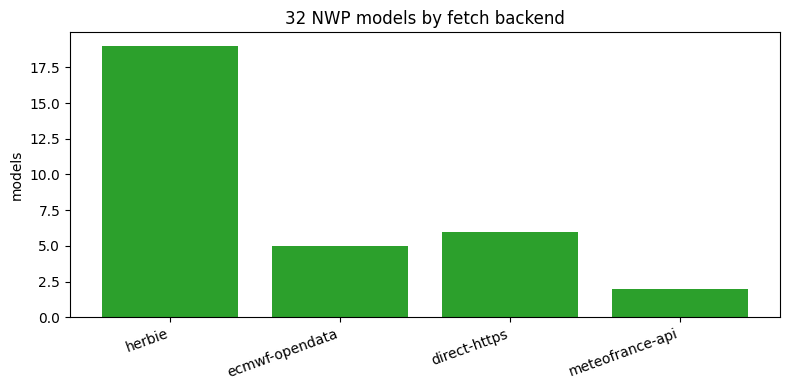

In [5]:
import matplotlib.pyplot as plt

by_backend = Counter(m.backend for m in cat.datasets.values())
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(by_backend), list(by_backend.values()), color='tab:green')
ax.set(ylabel='models', title=f'{len(cat.datasets)} NWP models by fetch backend')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()